<a href="https://colab.research.google.com/github/Mairakanwal888/Student-Grade-Analyzer/blob/main/employee_salary_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving employee_salary_career_analysis.csv to employee_salary_career_analysis.csv


In [3]:
df = pd.read_csv("employee_salary_career_analysis.csv")

In [4]:
df.head()

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
2,EMP1003,35,Male,Bachelor,IT,Marketing Specialist,6.0,91000.0
3,EMP1004,28,Female,Bachelor,Operations,Financial Analyst,0.0,76500.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0


In [5]:
df.tail()

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
297,EMP1298,57,Female,Master,Finance,Software Engineer,23.0,184500.0
298,EMP1299,44,Male,High School,Sales,Data Analyst,12.0,124000.0
299,EMP1300,49,Female,Bachelor,Operations,Project Manager,13.0,149000.0
300,EMP1011,44,Female,High School,Sales,Project Manager,12.0,122500.0
301,EMP1026,45,Male,Bachelor,Operations,Project Manager,18.0,156000.0


In [6]:
df.sample(5)

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
14,EMP1015,23,Male,Bachelor,Sales,Data Analyst,2.0,72500.0
123,EMP1124,33,Male,Master,Sales,Data Analyst,7.0,113500.0
177,EMP1178,57,Female,Bachelor,Sales,Project Manager,24.0,191000.0
281,EMP1282,54,Male,Bachelor,HR,HR Specialist,23.0,177500.0
134,EMP1135,56,Female,Master,Marketing,Marketing Specialist,22.0,180500.0


In [7]:
df.shape

(302, 8)

In [8]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education', 'Department', 'Job_Role',
       'Experience_Years', 'Salary'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       302 non-null    object 
 1   Age               302 non-null    int64  
 2   Gender            302 non-null    object 
 3   Education         300 non-null    object 
 4   Department        301 non-null    object 
 5   Job_Role          302 non-null    object 
 6   Experience_Years  301 non-null    float64
 7   Salary            301 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 19.0+ KB


In [10]:
df.describe()

,Age,Experience_Years,Salary
count,302.000000,301.000000,301.000000
mean,41.178808,12.657807,132317.275748
std,11.855490,7.836614,38861.289658
min,21.000000,0.000000,42000.000000
25%,31.000000,6.000000,102000.000000
50%,43.000000,13.000000,136000.000000
75%,52.000000,19.000000,161000.000000
max,60.000000,29.000000,220000.000000


In [11]:
df.describe(include="object")

,Employee_ID,Gender,Education,Department,Job_Role
count,302,302,300,301,302
unique,300,2,4,6,8
top,EMP1026,Male,Bachelor,IT,Project Manager
freq,2,154,163,56,46


In [12]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education,2
Department,1
Job_Role,0
Experience_Years,1
Salary,1


In [13]:
(df.isnull().sum() / len(df)) * 100

,0
Employee_ID,0.000000
Age,0.000000
Gender,0.000000
Education,0.662252
Department,0.331126
Job_Role,0.000000
Experience_Years,0.331126
Salary,0.331126


In [14]:
df.duplicated().sum()

np.int64(2)

In [15]:
df[df.duplicated()]

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
300,EMP1011,44,Female,High School,Sales,Project Manager,12.0,122500.0
301,EMP1026,45,Male,Bachelor,Operations,Project Manager,18.0,156000.0


In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["Education"].unique()

array(['High School', 'Bachelor', 'Master', nan, 'PhD'], dtype=object)

In [19]:
df["Department"].unique()

array(['Sales', 'Finance', 'IT', 'Operations', 'Marketing', 'HR', nan],
      dtype=object)

In [20]:
df["Job_Role"].unique()

array(['Financial Analyst', 'Project Manager', 'Marketing Specialist',
       'Software Engineer', 'Data Analyst', 'Operations Manager',
       'HR Specialist', 'Sales Executive'], dtype=object)

In [21]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [23]:
df["Education"].value_counts()

,count
Education,
Bachelor,162
Master,82
High School,33
PhD,21


In [24]:
df["Department"].value_counts()

,count
Department,
IT,56
Finance,55
Operations,54
HR,53
Sales,44
Marketing,37


In [25]:
df["Job_Role"].value_counts()

,count
Job_Role,
Project Manager,44
Financial Analyst,41
Marketing Specialist,40
HR Specialist,39
Operations Manager,38
Software Engineer,35
Data Analyst,32
Sales Executive,31


In [26]:
df["Gender"].value_counts()

,count
Gender,
Male,153
Female,147


In [27]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education,2
Department,1
Job_Role,0
Experience_Years,1
Salary,1


In [28]:
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

In [29]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

In [30]:
df["Experience_Years"] = df["Experience_Years"].fillna(
    df["Experience_Years"].median()
)

In [31]:
df["Salary"] = df["Salary"].fillna(
    df["Salary"].median()
)

In [32]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education,0
Department,0
Job_Role,0
Experience_Years,0
Salary,0


In [33]:
df.dtypes

,0
Employee_ID,object
Age,int64
Gender,object
Education,object
Department,object
Job_Role,object
Experience_Years,float64
Salary,float64


In [34]:
df["Experience_Years"] = df["Experience_Years"].astype(int)

In [35]:
df["Salary"] = df["Salary"].astype(int)

In [36]:
df["Salary"].mean()

np.float64(132283.33333333334)

In [37]:
df["Salary"].median()

136000.0

In [38]:
df["Salary"].mode()

,Salary
0,162500


In [39]:
df["Salary"].min()

42000

In [40]:
df["Salary"].max()

220000

In [41]:
df["Salary"].std()

38898.543819271086

In [42]:
df["Salary"].var()

1513096711.259753

In [43]:
df["Age"].mean()

np.float64(41.156666666666666)

In [44]:
df["Age"].median()

42.5

In [45]:
df["Age"].min()

21

In [46]:
df["Age"].max()

60

In [47]:
df["Age"].std()

11.891881475991045

In [48]:
df["Experience_Years"].mean()

np.float64(12.643333333333333)

In [49]:
df["Experience_Years"].median()

13.0

In [50]:
df["Experience_Years"].min()

0

In [51]:
df["Experience_Years"].max()

29

In [52]:
df["Experience_Years"].std()

7.843544662020223

In [53]:
df.groupby("Department")["Salary"].mean()

,Salary
Department,
Finance,137063.636364
HR,129575.471698
IT,134728.070175
Marketing,133135.135135
Operations,131250.000000
Sales,126954.545455


In [54]:
df.groupby("Department")["Salary"].median()

,Salary
Department,
Finance,137000.0
HR,135000.0
IT,139000.0
Marketing,147500.0
Operations,133500.0
Sales,123750.0


In [55]:
df.groupby("Department")["Salary"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

,count,mean,median,min,max,std
Department,,,,,,
Finance,55,137063.636364,137000.0,58500,220000,37469.253389
HR,53,129575.471698,135000.0,51500,197500,38461.943757
IT,57,134728.070175,139000.0,63000,210000,36911.461414
Marketing,37,133135.135135,147500.0,45000,216000,42528.201207
Operations,54,131250.000000,133500.0,42000,200000,39453.071000
Sales,44,126954.545455,123750.0,63500,211500,41048.017568


In [56]:
df.groupby("Education")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Education,,,,,
Bachelor,164,131274.390244,137500.0,42000,206500
High School,33,120484.848485,119500.0,58500,211500
Master,82,136323.170732,138750.0,66000,210000
PhD,21,142928.571429,133000.0,82500,220000


In [57]:
df.groupby("Job_Role")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

,count,mean,median,min,max
Job_Role,,,,,
Operations Manager,38,143394.736842,145500.0,62500,206500
Marketing Specialist,40,140600.000000,145500.0,62000,197000
Software Engineer,35,140328.571429,148000.0,63000,211500
Project Manager,44,134306.818182,132250.0,63000,216000
HR Specialist,39,129961.538462,133500.0,42000,210000
Financial Analyst,41,128426.829268,127500.0,61000,197500
Data Analyst,32,128156.250000,124750.0,63000,220000
Sales Executive,31,108258.064516,104500.0,45000,206500


In [58]:
df.groupby("Gender")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Gender,,,,,
Female,147,132051.020408,136000.0,42000,220000
Male,153,132506.535948,136000.0,45000,211500


In [59]:
df.groupby(["Department", "Education"])["Salary"].mean()

Department  Education  
Finance     Bachelor       132869.565217
            High School    108950.000000
            Master         150166.666667
            PhD            172500.000000
HR          Bachelor       130208.333333
            High School    129250.000000
            Master         120125.000000
            PhD            137214.285714
IT          Bachelor       123666.666667
            High School    154300.000000
            Master         147187.500000
            PhD            157333.333333
Marketing   Bachelor       128869.565217
            High School     95500.000000
            Master         140250.000000
            PhD            154666.666667
Operations  Bachelor       138107.142857
            High School    113833.333333
            Master         130647.058824
            PhD            105500.000000
Sales       Bachelor       136833.333333
            High School    119777.777778
            Master         118153.846154
            PhD             98500.000000
Name: Salary, dtype: float64

In [60]:
df.sort_values("Salary", ascending=False).head(10)

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
149,EMP1150,59,Female,PhD,Finance,Data Analyst,24,220000
292,EMP1293,48,Female,PhD,Marketing,Project Manager,26,216000
248,EMP1249,60,Male,High School,Sales,Software Engineer,29,211500
155,EMP1156,59,Female,Master,IT,HR Specialist,25,210000
250,EMP1251,55,Male,Master,IT,Sales Executive,26,206500
186,EMP1187,52,Female,Bachelor,Finance,Operations Manager,24,206500
51,EMP1052,60,Female,Bachelor,Sales,Software Engineer,25,206000
11,EMP1012,56,Female,Bachelor,Operations,Operations Manager,23,200000
213,EMP1214,53,Female,Master,Finance,Software Engineer,24,200000
277,EMP1278,58,Female,PhD,HR,Financial Analyst,24,197500


In [61]:
df.sort_values("Salary").head(10)

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
52,EMP1053,24,Female,Bachelor,Operations,HR Specialist,0,42000
218,EMP1219,21,Male,Bachelor,Marketing,Sales Executive,0,45000
42,EMP1043,22,Male,Bachelor,HR,Sales Executive,0,51500
54,EMP1055,26,Female,High School,Finance,Sales Executive,0,58500
20,EMP1021,22,Male,Bachelor,Operations,HR Specialist,2,60500
82,EMP1083,21,Female,High School,Finance,Financial Analyst,0,61000
37,EMP1038,24,Female,Bachelor,Marketing,Marketing Specialist,0,62000
212,EMP1213,27,Female,Bachelor,HR,Operations Manager,3,62500
262,EMP1263,24,Female,Bachelor,IT,Project Manager,0,63000
194,EMP1195,26,Male,Bachelor,HR,Financial Analyst,0,63000


In [3]:
from google.colab import files

uploaded = files.upload()

Saving employee_salary_career_analysis.csv to employee_salary_career_analysis.csv


In [4]:
import pandas as pd

df = pd.read_csv("employee_salary_career_analysis.csv")

In [5]:
df.head()

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
2,EMP1003,35,Male,Bachelor,IT,Marketing Specialist,6.0,91000.0
3,EMP1004,28,Female,Bachelor,Operations,Financial Analyst,0.0,76500.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0


In [6]:
df.sort_values("Experience_Years", ascending=False).head(10)


,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
248,EMP1249,60,Male,High School,Sales,Software Engineer,29.0,211500.0
5,EMP1006,59,Female,Master,Sales,Marketing Specialist,27.0,193000.0
125,EMP1126,59,Female,Bachelor,Sales,Operations Manager,27.0,183000.0
98,EMP1099,54,Male,Bachelor,IT,Financial Analyst,27.0,195500.0
234,EMP1235,52,Male,High School,Operations,Operations Manager,26.0,188000.0
190,EMP1191,58,Female,Bachelor,Operations,HR Specialist,26.0,186000.0
247,EMP1248,58,Male,Bachelor,Operations,Project Manager,26.0,186000.0
292,EMP1293,48,Female,PhD,Marketing,Project Manager,26.0,216000.0
117,EMP1118,59,Female,Bachelor,Operations,Operations Manager,26.0,189000.0
250,EMP1251,55,Male,Master,IT,Sales Executive,26.0,206500.0


In [7]:
df[df["Salary"] > 150000]

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
5,EMP1006,59,Female,Master,Sales,Marketing Specialist,27.0,193000.0
11,EMP1012,56,Female,Bachelor,Operations,Operations Manager,23.0,200000.0
12,EMP1013,60,Male,Bachelor,HR,Marketing Specialist,25.0,188500.0
...,...,...,...,...,...,...,...,...
290,EMP1291,55,Male,Bachelor,HR,Project Manager,23.0,178000.0
292,EMP1293,48,Female,PhD,Marketing,Project Manager,26.0,216000.0
293,EMP1294,50,Female,Bachelor,Sales,Operations Manager,22.0,170000.0
297,EMP1298,57,Female,Master,Finance,Software Engineer,23.0,184500.0


In [8]:
df[df["Experience_Years"] > 10]

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0
5,EMP1006,59,Female,Master,Sales,Marketing Specialist,27.0,193000.0
6,EMP1007,39,Female,Bachelor,Finance,Software Engineer,12.0,143500.0
...,...,...,...,...,...,...,...,...
297,EMP1298,57,Female,Master,Finance,Software Engineer,23.0,184500.0
298,EMP1299,44,Male,High School,Sales,Data Analyst,12.0,124000.0
299,EMP1300,49,Female,Bachelor,Operations,Project Manager,13.0,149000.0
300,EMP1011,44,Female,High School,Sales,Project Manager,12.0,122500.0


In [9]:
df[df["Department"] == "IT"]

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
2,EMP1003,35,Male,Bachelor,IT,Marketing Specialist,6.0,91000.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0
13,EMP1014,44,Male,Master,IT,HR Specialist,11.0,133500.0
19,EMP1020,58,Male,Bachelor,IT,Project Manager,21.0,186500.0
23,EMP1024,32,Female,Bachelor,IT,Software Engineer,18.0,162500.0
34,EMP1035,29,Male,Bachelor,IT,Software Engineer,11.0,136000.0
45,EMP1046,27,Male,Bachelor,IT,Financial Analyst,4.0,89500.0
53,EMP1054,22,Female,Bachelor,IT,Sales Executive,3.0,74000.0
61,EMP1062,56,Male,High School,IT,Sales Executive,20.0,139000.0
67,EMP1068,43,Male,Master,IT,Marketing Specialist,17.0,162000.0


In [10]:
df[df["Education"] == "Master"]

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
5,EMP1006,59,Female,Master,Sales,Marketing Specialist,27.0,193000.0
7,EMP1008,43,Female,Master,Marketing,Data Analyst,10.0,126500.0
8,EMP1009,31,Female,Master,Operations,Project Manager,6.0,118000.0
13,EMP1014,44,Male,Master,IT,HR Specialist,11.0,133500.0
18,EMP1019,50,Female,Master,Operations,Data Analyst,14.0,138500.0
...,...,...,...,...,...,...,...,...
282,EMP1283,41,Female,Master,IT,Operations Manager,11.0,144000.0
283,EMP1284,50,Male,Master,Finance,HR Specialist,16.0,158000.0
288,EMP1289,39,Male,Master,Operations,Software Engineer,16.0,159500.0
291,EMP1292,37,Female,Master,Finance,Sales Executive,11.0,127000.0


In [11]:
df[
    (df["Experience_Years"] > 10) &
    (df["Salary"] > 100000)
]

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0
5,EMP1006,59,Female,Master,Sales,Marketing Specialist,27.0,193000.0
6,EMP1007,39,Female,Bachelor,Finance,Software Engineer,12.0,143500.0
...,...,...,...,...,...,...,...,...
297,EMP1298,57,Female,Master,Finance,Software Engineer,23.0,184500.0
298,EMP1299,44,Male,High School,Sales,Data Analyst,12.0,124000.0
299,EMP1300,49,Female,Bachelor,Operations,Project Manager,13.0,149000.0
300,EMP1011,44,Female,High School,Sales,Project Manager,12.0,122500.0


In [12]:
df["Salary_K"] = df["Salary"] / 1000

In [13]:
df.head()

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary,Salary_K
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0,169.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0,161.0
2,EMP1003,35,Male,Bachelor,IT,Marketing Specialist,6.0,91000.0,91.0
3,EMP1004,28,Female,Bachelor,Operations,Financial Analyst,0.0,76500.0,76.5
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0,117.0


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("employee_salary_career_analysis.csv")

In [17]:
df.head()

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
2,EMP1003,35,Male,Bachelor,IT,Marketing Specialist,6.0,91000.0
3,EMP1004,28,Female,Bachelor,Operations,Financial Analyst,0.0,76500.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0


In [18]:
print(df.columns)

Index(['Employee_ID', 'Age', 'Gender', 'Education', 'Department', 'Job_Role',
       'Experience_Years', 'Salary'],
      dtype='object')


In [19]:
print(df["Salary"].head())
print(df["Salary"].dtype)

0    169000.0
1    161000.0
2     91000.0
3     76500.0
4    117000.0
Name: Salary, dtype: float64
float64


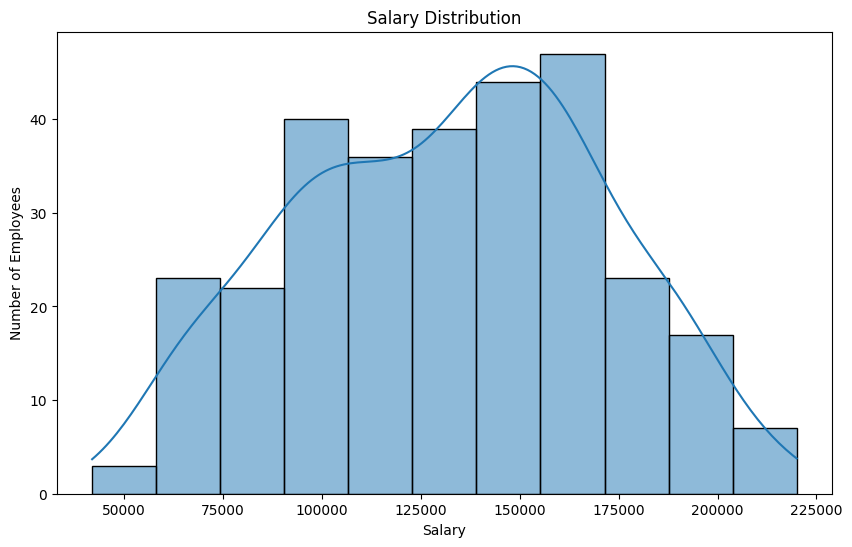

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Salary", kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

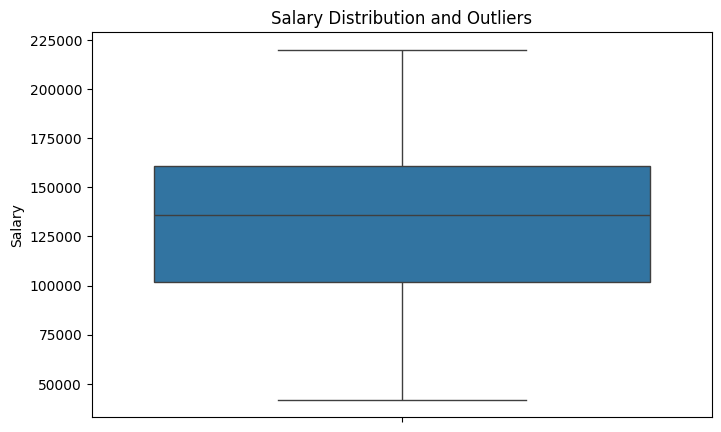

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Salary"])

plt.title("Salary Distribution and Outliers")
plt.ylabel("Salary")

plt.show()

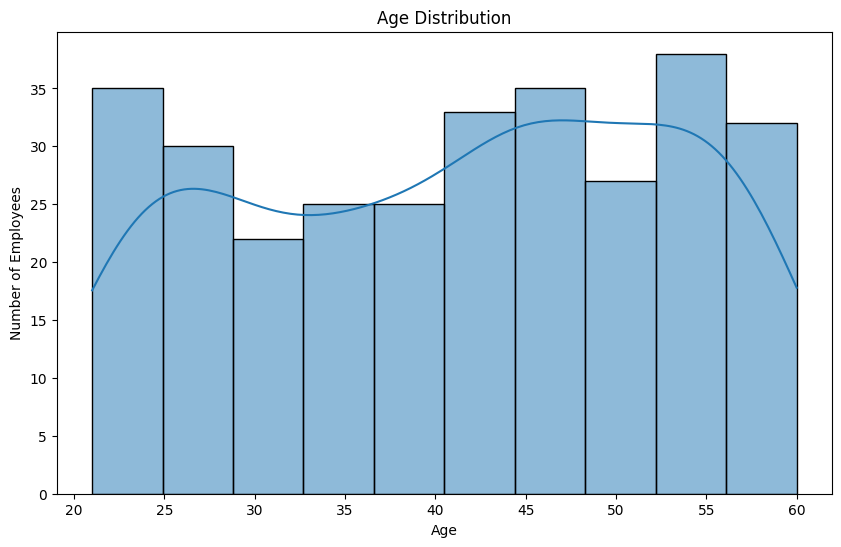

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

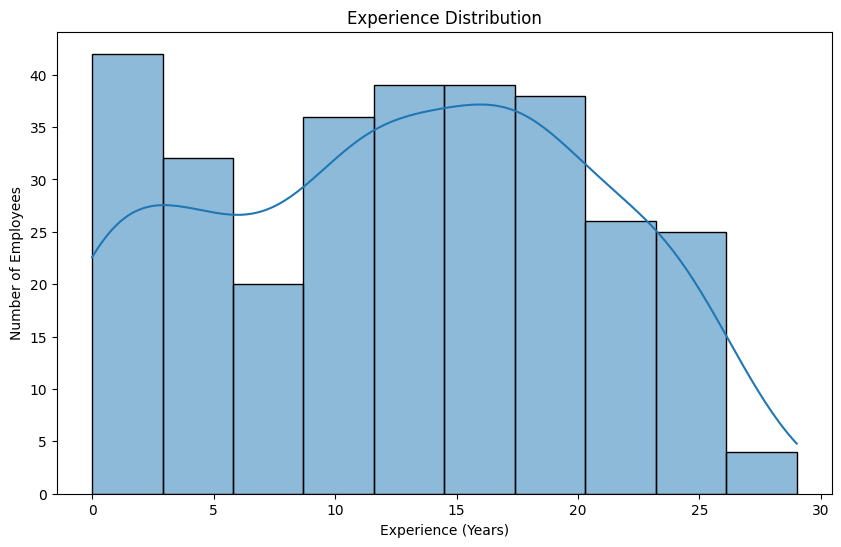

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Experience_Years"], kde=True)

plt.title("Experience Distribution")
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Employees")

plt.show()

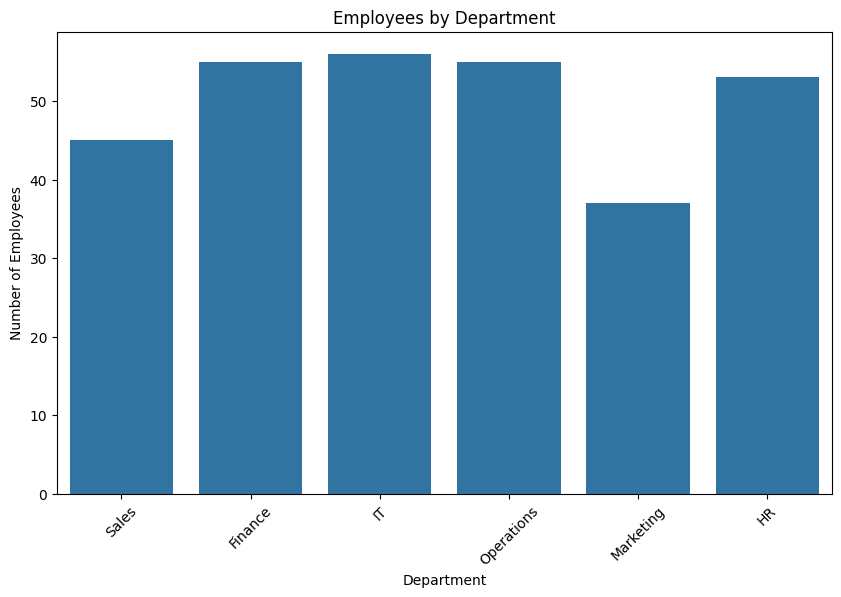

In [25]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Department")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45)

plt.show()

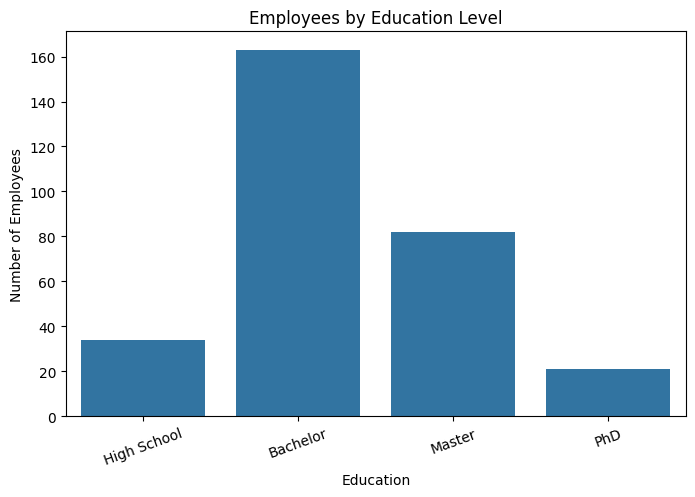

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Education")

plt.title("Employees by Education Level")
plt.xlabel("Education")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20)

plt.show()

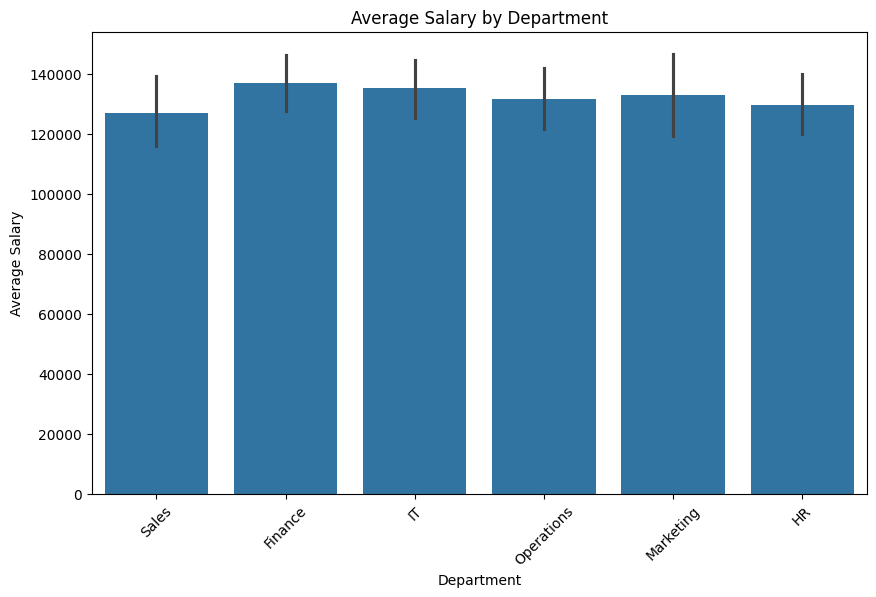

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Department",
    y="Salary"
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

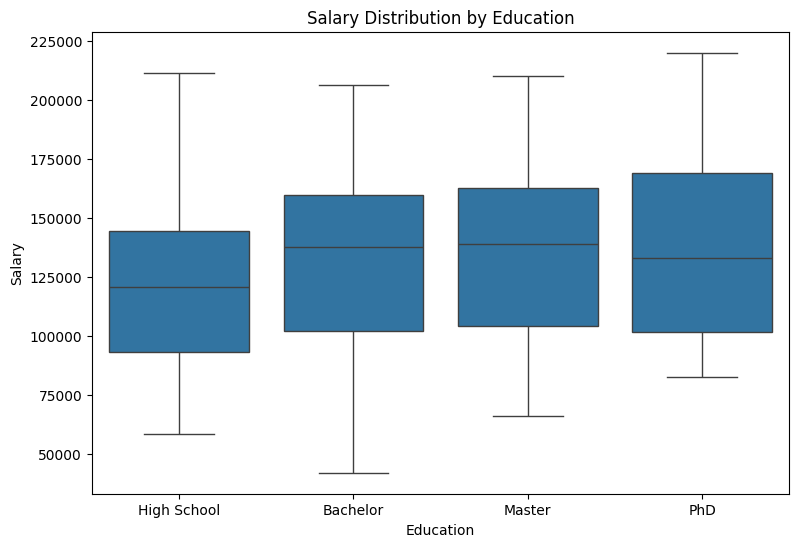

In [28]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Education",
    y="Salary"
)

plt.title("Salary Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Salary")

plt.show()

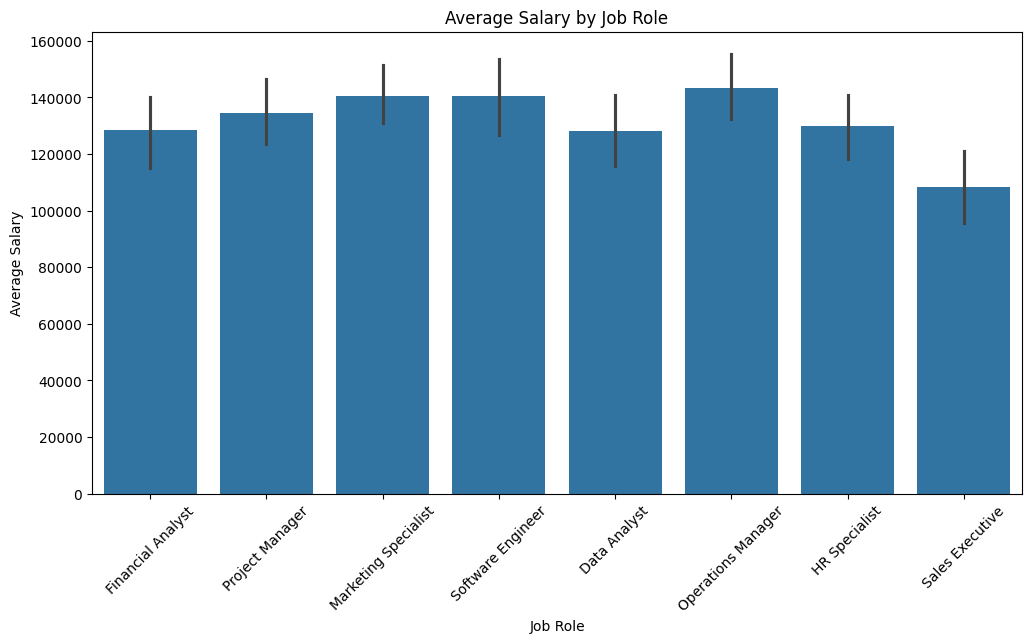

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Job_Role",
    y="Salary"
)

plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

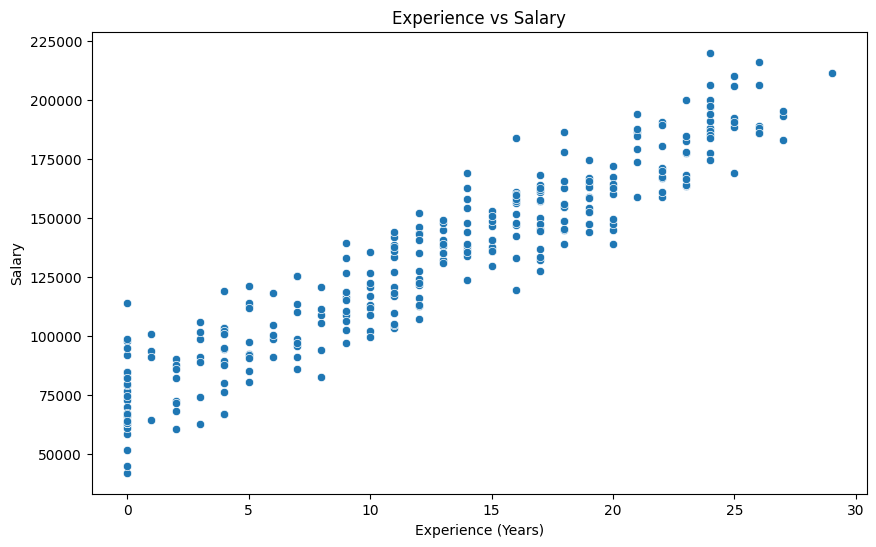

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Experience_Years",
    y="Salary"
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

plt.show()

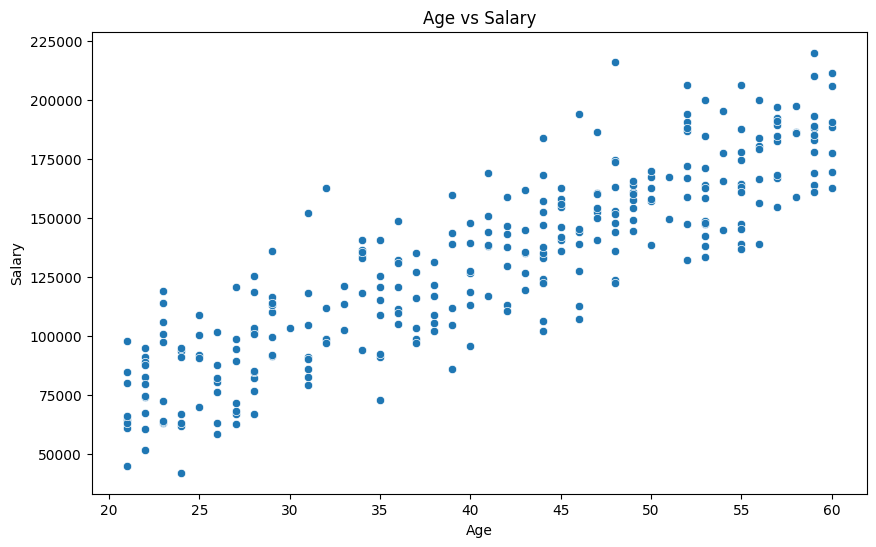

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Salary"
)

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

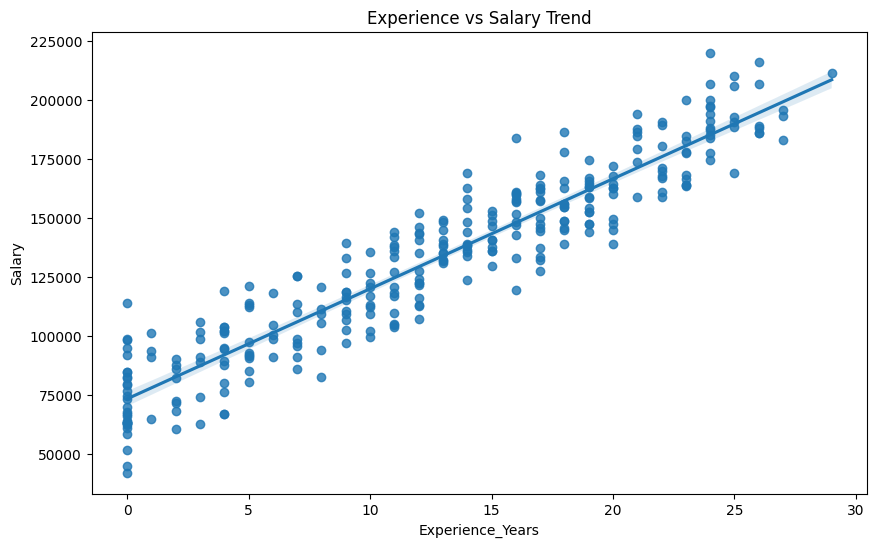

In [32]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Experience_Years",
    y="Salary"
)

plt.title("Experience vs Salary Trend")

plt.show()

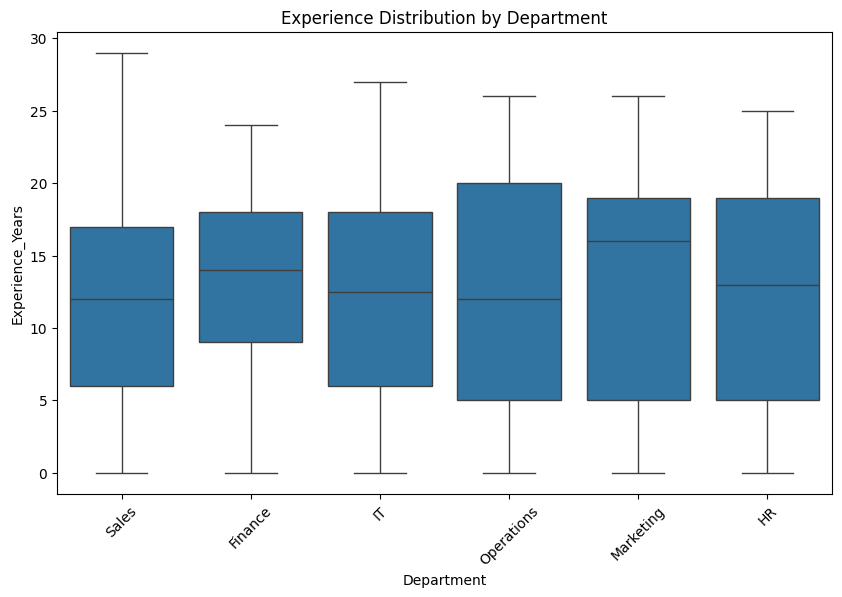

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Department",
    y="Experience_Years"
)

plt.title("Experience Distribution by Department")

plt.xticks(rotation=45)

plt.show()

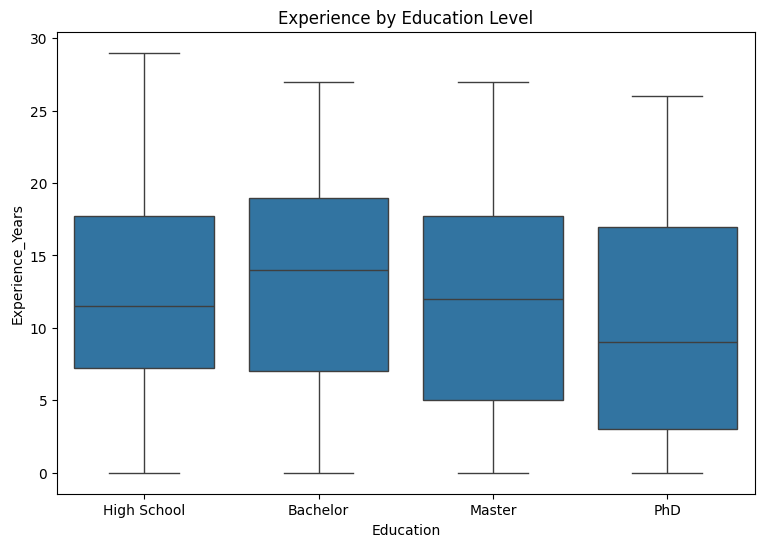

In [34]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Education",
    y="Experience_Years"
)

plt.title("Experience by Education Level")

plt.show()

In [35]:
numeric_df = df[
    ["Age", "Experience_Years", "Salary"]
]
numeric_df.corr()

,Age,Experience_Years,Salary
Age,1.000000,0.929823,0.874604
Experience_Years,0.929823,1.000000,0.941043
Salary,0.874604,0.941043,1.000000


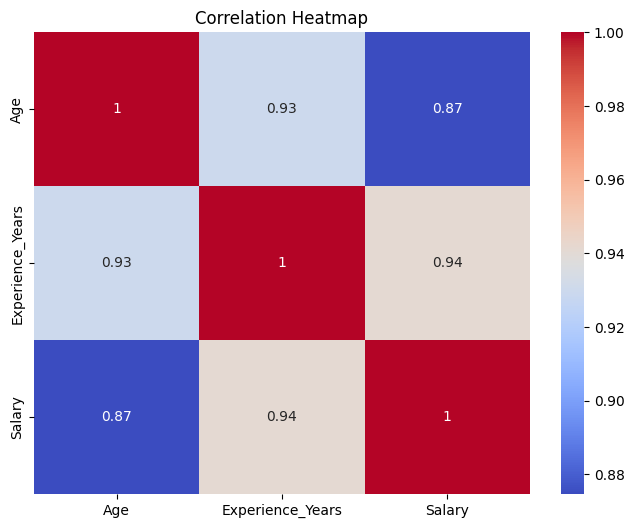

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [37]:
numeric_df.cov()

,Age,Experience_Years,Salary
Age,140.552639,86.166589,4.032457e+05
Experience_Years,86.166589,61.412514,2.868809e+05
Salary,403245.741971,286880.869565,1.510200e+09


In [38]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

In [39]:
IQR = Q3 - Q1

In [40]:
lower_bound = Q1 - 1.5 * IQR

In [41]:
upper_bound = Q3 + 1.5 * IQR

In [42]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 102000.0
Q3: 161000.0
IQR: 59000.0
Lower Bound: 13500.0
Upper Bound: 249500.0


In [43]:
salary_outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

salary_outliers

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary


In [44]:
len(salary_outliers)

0

In [45]:
(len(salary_outliers) / len(df)) * 100

0.0

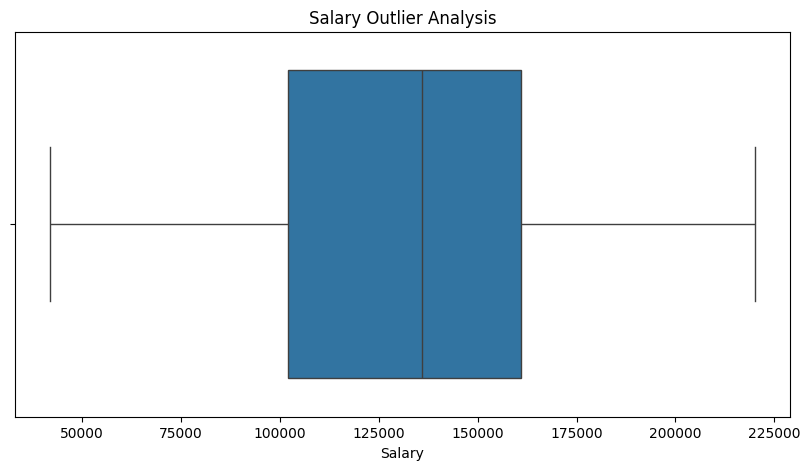

In [46]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Salary"])

plt.title("Salary Outlier Analysis")

plt.show()

In [47]:
top_10 = df.sort_values(
    "Salary",
    ascending=False
).head(10)

top_10

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
149,EMP1150,59,Female,PhD,Finance,Data Analyst,24.0,220000.0
292,EMP1293,48,Female,PhD,Marketing,Project Manager,26.0,216000.0
248,EMP1249,60,Male,High School,Sales,Software Engineer,29.0,211500.0
155,EMP1156,59,Female,Master,IT,HR Specialist,25.0,210000.0
250,EMP1251,55,Male,Master,IT,Sales Executive,26.0,206500.0
186,EMP1187,52,Female,Bachelor,Finance,Operations Manager,24.0,206500.0
51,EMP1052,60,Female,Bachelor,Sales,Software Engineer,25.0,206000.0
213,EMP1214,53,Female,Master,Finance,Software Engineer,24.0,200000.0
11,EMP1012,56,Female,Bachelor,Operations,Operations Manager,23.0,200000.0
277,EMP1278,58,Female,PhD,HR,Financial Analyst,24.0,197500.0


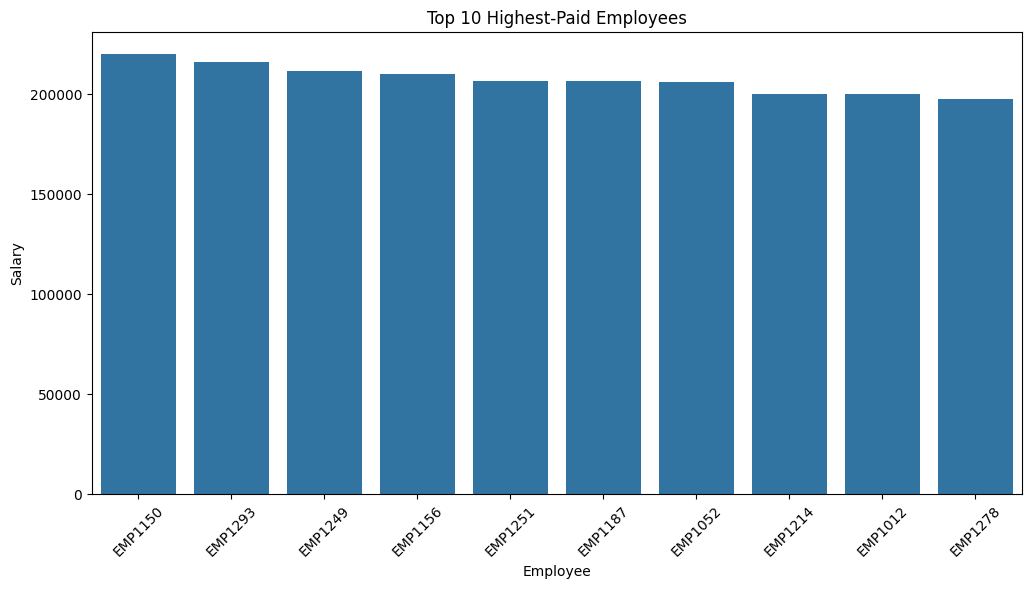

In [48]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10,
    x="Employee_ID",
    y="Salary"
)

plt.title("Top 10 Highest-Paid Employees")
plt.xlabel("Employee")
plt.ylabel("Salary")

plt.xticks(rotation=45)

plt.show()

In [49]:
department_salary = (
    df.groupby("Department")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

department_salary

,Salary
Department,
Finance,137063.636364
IT,135209.090909
Marketing,133135.135135
Operations,131700.000000
HR,129575.471698
Sales,126855.555556


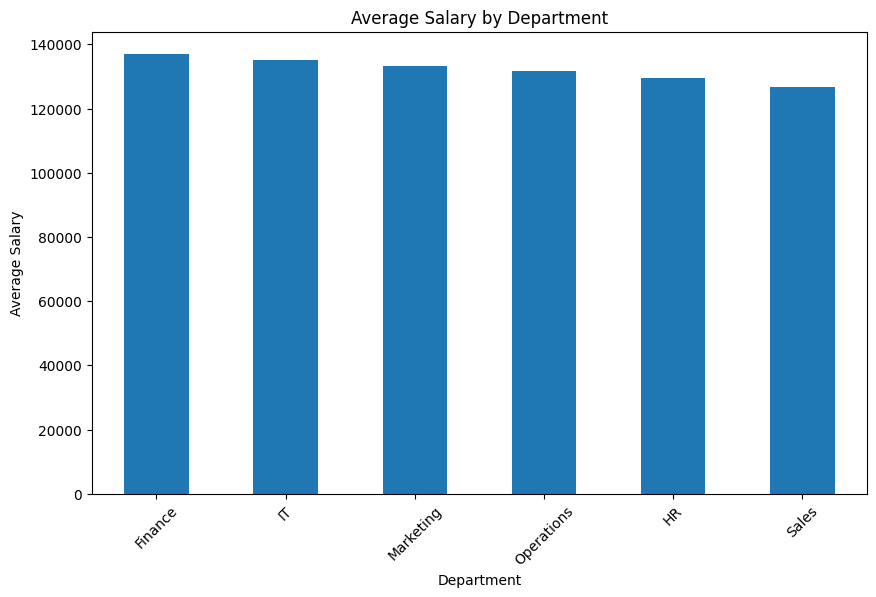

In [50]:
plt.figure(figsize=(10, 6))

department_salary.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

In [51]:
education_salary = (
    df.groupby("Education")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

education_salary

,Salary
Education,
PhD,142928.571429
Master,136323.170732
Bachelor,130873.456790
High School,120544.117647


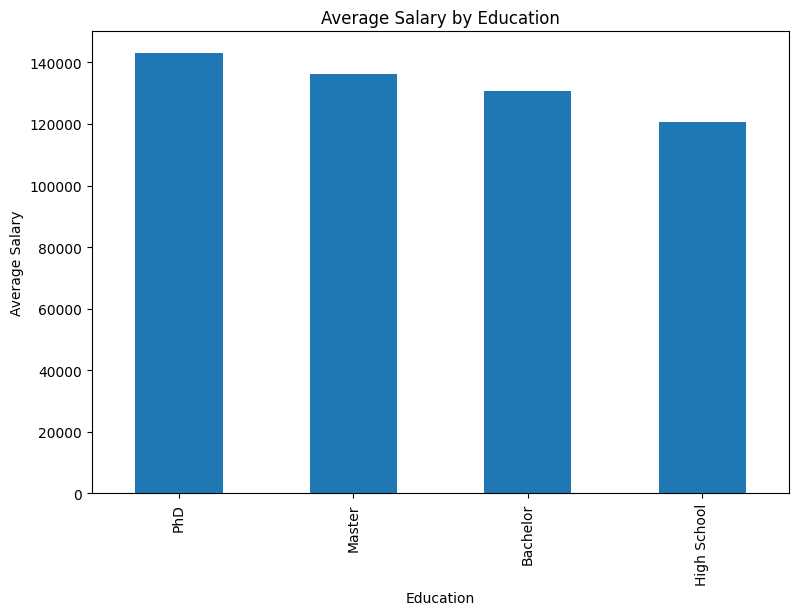

In [52]:
plt.figure(figsize=(9, 6))

education_salary.plot(kind="bar")

plt.title("Average Salary by Education")
plt.xlabel("Education")
plt.ylabel("Average Salary")

plt.show()

In [53]:
role_salary = (
    df.groupby("Job_Role")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

role_salary

,Salary
Job_Role,
Operations Manager,143394.736842
Marketing Specialist,140600.000000
Software Engineer,140455.882353
Project Manager,134521.739130
HR Specialist,129961.538462
Financial Analyst,128426.829268
Data Analyst,128156.250000
Sales Executive,108258.064516


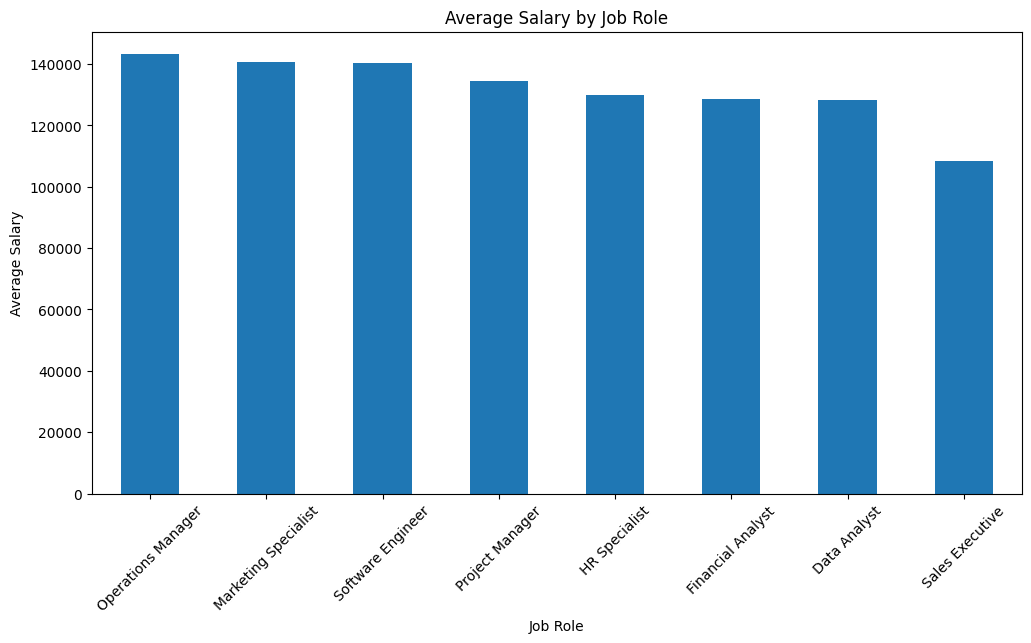

In [54]:
plt.figure(figsize=(12, 6))

role_salary.plot(kind="bar")

plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

In [55]:
df.head()

,Employee_ID,Age,Gender,Education,Department,Job_Role,Experience_Years,Salary
0,EMP1001,59,Male,High School,Sales,Financial Analyst,25.0,169000.0
1,EMP1002,49,Male,Bachelor,Finance,Project Manager,17.0,161000.0
2,EMP1003,35,Male,Bachelor,IT,Marketing Specialist,6.0,91000.0
3,EMP1004,28,Female,Bachelor,Operations,Financial Analyst,0.0,76500.0
4,EMP1005,41,Male,High School,IT,Marketing Specialist,11.0,117000.0


In [56]:
df.shape

(302, 8)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       302 non-null    object 
 1   Age               302 non-null    int64  
 2   Gender            302 non-null    object 
 3   Education         300 non-null    object 
 4   Department        301 non-null    object 
 5   Job_Role          302 non-null    object 
 6   Experience_Years  301 non-null    float64
 7   Salary            301 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 19.0+ KB


In [58]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education,2
Department,1
Job_Role,0
Experience_Years,1
Salary,1


In [59]:
df.duplicated().sum()

np.int64(2)

In [60]:
print("Average Salary:", df["Salary"].mean())
print("Median Salary:", df["Salary"].median())
print("Average Age:", df["Age"].mean())
print("Average Experience:", df["Experience_Years"].mean())
print("Number of Employees:", len(df))

Average Salary: 132317.2757475083
Median Salary: 136000.0
Average Age: 41.17880794701987
Average Experience: 12.6578073089701
Number of Employees: 302


In [61]:
print("Average Salary by Department:")
print(df.groupby("Department")["Salary"].mean().sort_values(ascending=False))

Average Salary by Department:
Department
Finance       137063.636364
IT            135209.090909
Marketing     133135.135135
Operations    131700.000000
HR            129575.471698
Sales         126855.555556
Name: Salary, dtype: float64


In [62]:
print("\nAverage Salary by Education:")
print(df.groupby("Education")["Salary"].mean().sort_values(ascending=False))


Average Salary by Education:
Education
PhD            142928.571429
Master         136323.170732
Bachelor       130873.456790
High School    120544.117647
Name: Salary, dtype: float64


In [63]:
print("\nAverage Salary by Job Role:")
print(df.groupby("Job_Role")["Salary"].mean().sort_values(ascending=False))


Average Salary by Job Role:
Job_Role
Operations Manager      143394.736842
Marketing Specialist    140600.000000
Software Engineer       140455.882353
Project Manager         134521.739130
HR Specialist           129961.538462
Financial Analyst       128426.829268
Data Analyst            128156.250000
Sales Executive         108258.064516
Name: Salary, dtype: float64
